# Smart E-Commerce Sales Analytics & Business Intelligence Dashboard

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Looker Studio
- Flutter

### Objective
To analyze e-commerce sales data, generate business insights, and build an interactive dashboard for decision-making.

In [2]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("E:\\ECommerce_Sales_Analysis\\dataset\\SampleSuperstore.csv")

In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 13)

In [6]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [56]:
df.insert(0, "Order_ID", ["ORD" + str(1001 + i) for i in range(len(df))])

In [57]:
df.head()

,Order_ID,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,...,Quantity,Discount,Profit,Delivery Status,Payment Mode,Order Priority,Festival Season,Delivery Days,Customer Rating,Warehouse
0,ORD1001,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,...,2,0.00,41.9136,Delivered,Cash on Delivery,High,No,1,4,Bengaluru
1,ORD1002,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,...,3,0.00,219.5820,Delivered,Cash on Delivery,High,Yes,2,5,Bengaluru
2,ORD1003,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,...,2,0.00,6.8714,Delivered,Net Banking,High,Yes,2,1,Mumbai
3,ORD1004,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,...,5,0.45,-383.0310,Returned,Credit Card,Medium,No,3,5,Bengaluru
4,ORD1005,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,...,2,0.20,2.5164,Delivered,Credit Card,Low,Yes,6,1,Bengaluru


In [60]:
df.to_csv("E:\\ECommerce_Sales_Analysis\\dataset\\Enhanced_Superstore.csv", index=False)

# Understanding the Dataset


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [8]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
payment_modes = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Cash on Delivery",
    "Net Banking"
]

df["Payment Mode"] = np.random.choice(
    payment_modes,
    size=len(df),
    p=[0.40, 0.25, 0.15, 0.15, 0.05]
)

df[["Payment Mode"]].head()

,Payment Mode
0,Cash on Delivery
1,Cash on Delivery
2,Net Banking
3,Credit Card
4,Credit Card


## Delivery Status

In [13]:
delivery_status = [
    "Delivered",
    "In Transit",
    "Returned",
    "Cancelled"
]

df["Delivery Status"] = np.random.choice(
    delivery_status,
    size=len(df),
    p=[0.85, 0.08, 0.05, 0.02]
)

In [14]:
order_priority = [
    "High",
    "Medium",
    "Low"
]

df["Order Priority"] = np.random.choice(
    order_priority,
    size=len(df),
    p=[0.25, 0.60, 0.15]
)

In [15]:
festival = [
    "Yes",
    "No"
]

df["Festival Season"] = np.random.choice(
    festival,
    size=len(df),
    p=[0.30, 0.70]
)

In [16]:
def delivery_days(priority):
    if priority == "High":
        return np.random.randint(1, 3)      # 1-2 days
    elif priority == "Medium":
        return np.random.randint(3, 6)      # 3-5 days
    else:
        return np.random.randint(5, 8)      # 5-7 days

df["Delivery Days"] = df["Order Priority"].apply(delivery_days)

In [17]:
def customer_rating(sales):
    if sales >= 500:
        return 5
    elif sales >= 200:
        return 4
    elif sales >= 100:
        return 3
    elif sales >= 50:
        return 2
    else:
        return 1

df["Customer Rating"] = df["Sales"].apply(customer_rating)

In [18]:
warehouse_map = {
    "West": "Mumbai",
    "East": "Kolkata",
    "South": "Bengaluru",
    "Central": "Hyderabad"
}

df["Warehouse"] = df["Region"].map(warehouse_map)

In [19]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Delivery Status,Payment Mode,Order Priority,Festival Season,Delivery Days,Customer Rating,Warehouse
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,Delivered,Cash on Delivery,High,No,1,4,Bengaluru
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,Delivered,Cash on Delivery,High,Yes,2,5,Bengaluru
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,Delivered,Net Banking,High,Yes,2,1,Mumbai
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,Returned,Credit Card,Medium,No,3,5,Bengaluru
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,Delivered,Credit Card,Low,Yes,6,1,Bengaluru


In [21]:
df.to_csv("E:\\ECommerce_Sales_Analysis\\dataset\\SampleSuperstore.csv", index=False)

# Data Cleaning

In [22]:
df.duplicated().sum()

np.int64(1)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.duplicated().sum()

np.int64(0)

## Duplicate Value Handling

The dataset was checked for duplicate records. One duplicate row was found and removed successfully using the `drop_duplicates()` function.

In [25]:
total_sales = df["Sales"].sum()
print(f"Total Sales: {total_sales:.2f}")

Total Sales: 2297151.74


In [26]:
total_profit = df["Profit"].sum()
print(f"Total Profit: {total_profit:.2f}")

Total Profit: 286373.94


In [27]:
total_quantity = df["Quantity"].sum()
print(f"Total Quantity Sold: {total_quantity}")

Total Quantity Sold: 37869


In [28]:
average_sales = df["Sales"].mean()
print(f"Average Sales: {average_sales:.2f}")

Average Sales: 229.88


In [29]:
highest_sale = df["Sales"].max()
print(f"Highest Sale: {highest_sale:.2f}")

Highest Sale: 22638.48


In [30]:
lowest_sale = df["Sales"].min()
print(f"Lowest Sale: {lowest_sale:.2f}")

Lowest Sale: 0.44


# Category-wise Sales Analysis

In [31]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    718997.9120
Technology         836154.0330
Name: Sales, dtype: float64


### Business Insight

Technology generated the highest sales among all product categories, making it the strongest revenue contributor. Furniture ranked second, while Office Supplies recorded the lowest sales. This suggests that the company should continue investing in Technology products while exploring strategies to improve sales in the Office Supplies category.

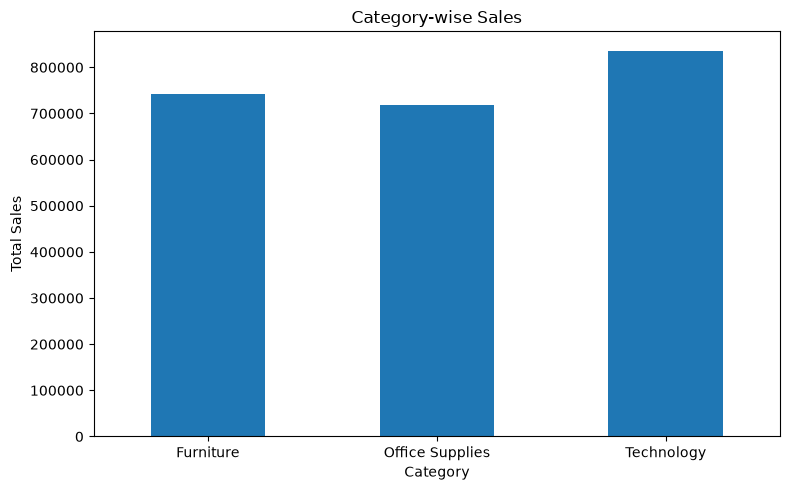

In [33]:
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

Technology generated the highest sales among all categories, followed by Furniture and Office Supplies. This indicates that Technology products are the major revenue contributors for the business. The company can focus on expanding Technology products while improving the performance of Office Supplies through promotions or better marketing strategies.

# Region-wise Sales Analysis

In [34]:
region_sales = df.groupby("Region")["Sales"].sum()

print(region_sales)

Region
Central    501239.8908
East       678732.1200
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


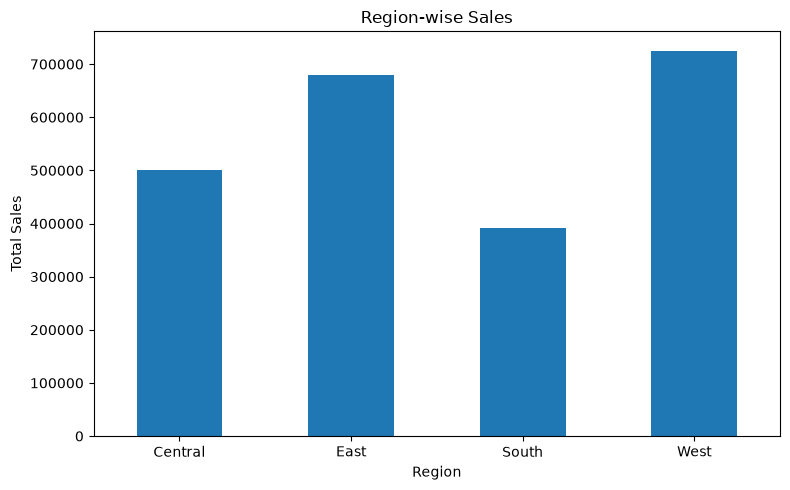

In [35]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

The West region recorded the highest sales, indicating strong business performance in that region. The South region generated the lowest sales, suggesting an opportunity for the company to improve its market presence through targeted marketing campaigns and promotional activities.

# State-Wise-Sales-Analysis

In [37]:
state_sales = df.groupby("State")["Sales"].sum()

state_sales = state_sales.sort_values(ascending=False)

print(state_sales)


State
California              457687.6315
New York                310827.1510
Texas                   170188.0458
Washington              138641.2700
Pennsylvania            116511.9140
Florida                  89473.7080
Illinois                 80166.1010
Ohio                     78258.1360
Michigan                 76269.6140
Virginia                 70636.7200
North Carolina           55603.1640
Indiana                  53555.3600
Georgia                  49095.8400
Kentucky                 36591.7500
New Jersey               35764.3120
Arizona                  35282.0010
Wisconsin                32114.6100
Colorado                 32108.1180
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27451.0690
Maryland                 23705.5230
Rhode Island             22627.9560
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

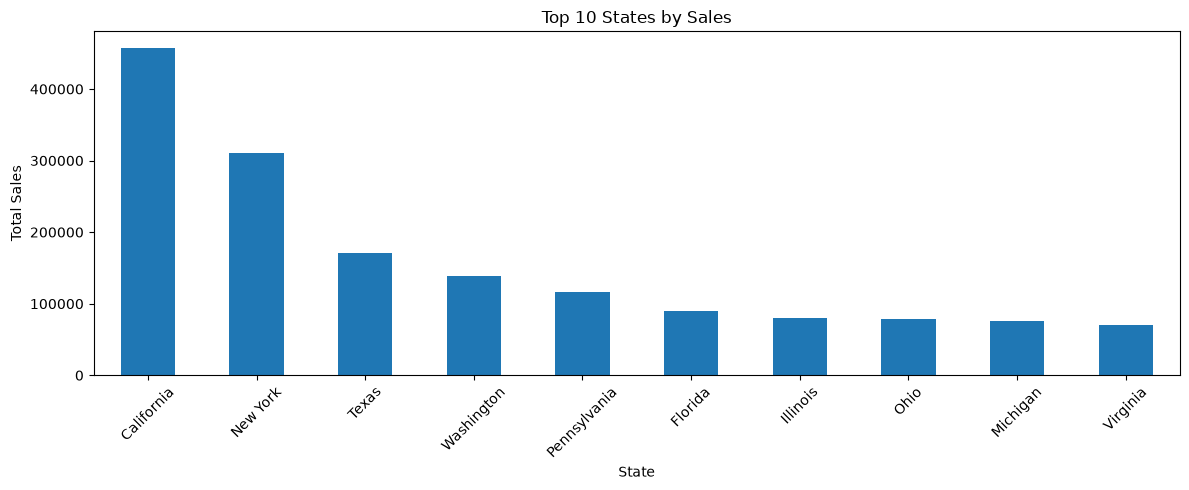

In [38]:
state_sales.head(10).plot(kind="bar", figsize=(12,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

The state-wise sales analysis shows that California recorded the highest sales, followed by New York and Texas. This indicates that these states are the company's strongest markets and contribute significantly to overall revenue.

On the other hand, states such as North Dakota, West Virginia, Maine, South Dakota, and Wyoming generated the lowest sales. These regions may require targeted marketing campaigns, better product availability, or promotional offers to improve business performance.

The analysis helps the company identify high-performing states for expansion and low-performing states where strategic improvements are needed.

### Recommendation

The company should continue investing in high-performing states such as California and New York while implementing region-specific marketing strategies, discounts, and promotional campaigns in low-performing states to increase sales and improve market reach.

# Payment Mode Analysis

In [40]:
payment_mode = df["Payment Mode"].value_counts()

print(payment_mode)

Payment Mode
UPI                 3939
Credit Card         2548
Cash on Delivery    1521
Debit Card          1479
Net Banking          506
Name: count, dtype: int64


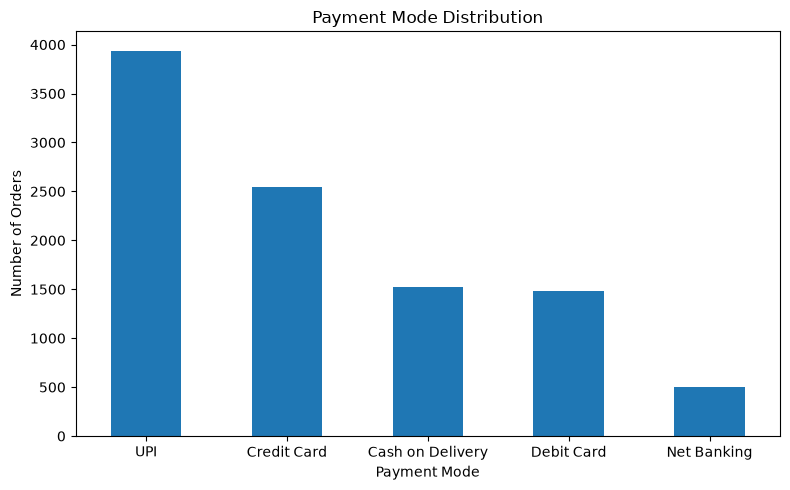

In [41]:
payment_mode.plot(kind="bar", figsize=(8,5))

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

The analysis shows that UPI is the most preferred payment method, accounting for the highest number of transactions. Credit Card is the second most popular payment option, while Net Banking is used the least. This indicates that customers prefer fast and convenient digital payment methods. The company can continue improving UPI payment services and offer cashback or discounts on less frequently used payment methods to encourage their adoption.

# Delivery Status Analysis

In [43]:
delivery_status = df["Delivery Status"].value_counts()

print(delivery_status)

Delivery Status
Delivered     8514
In Transit     777
Returned       490
Cancelled      212
Name: count, dtype: int64


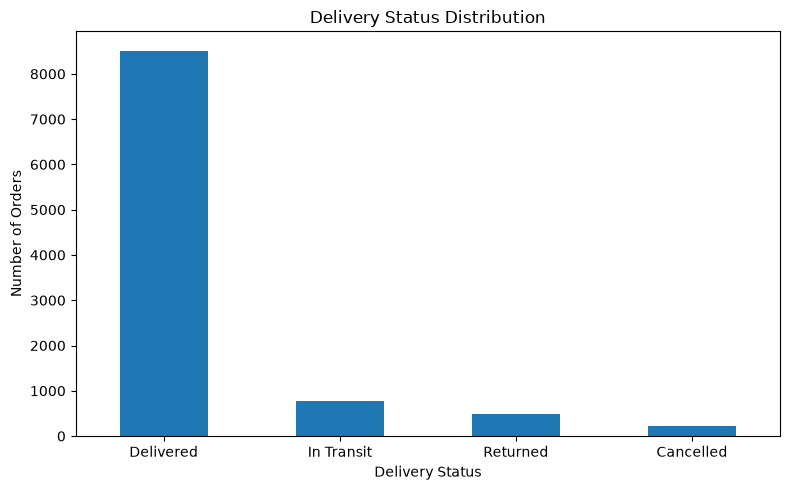

In [44]:
delivery_status.plot(kind="bar", figsize=(8,5))

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()


### Business Insight

The delivery status analysis indicates excellent operational performance, with the majority of orders successfully delivered. A small percentage of orders are still in transit, while returned and cancelled orders remain relatively low. Maintaining a high delivery success rate improves customer satisfaction, whereas reducing returned and cancelled orders can further increase profitability.

# Order Priority Analysis

In [45]:
priority = df["Order Priority"].value_counts()

print(priority)

Order Priority
Medium    5946
High      2545
Low       1502
Name: count, dtype: int64


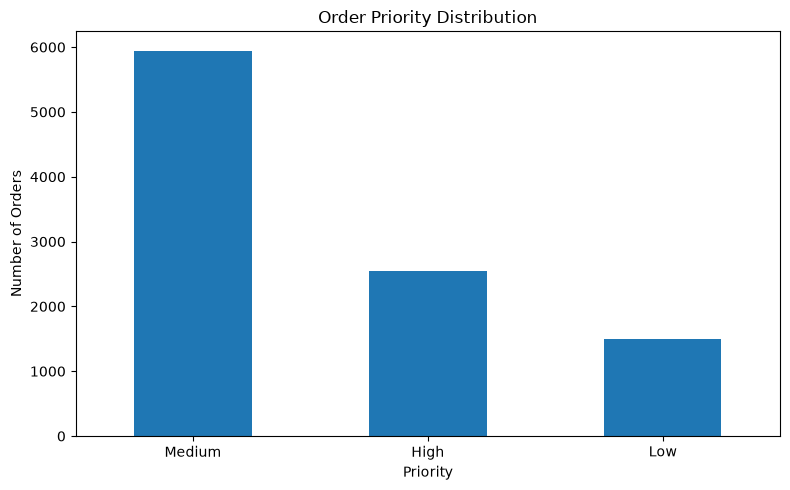

In [46]:
priority.plot(kind="bar", figsize=(8,5))

plt.title("Order Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

Most customer orders fall under the Medium priority category, indicating that regular orders form the largest portion of the business. High priority orders represent urgent customer requirements, while Low priority orders are comparatively fewer. This distribution helps the company allocate logistics resources efficiently and maintain timely deliveries.

# Festival Season Analysis

In [47]:
festival = df["Festival Season"].value_counts()

print(festival)

Festival Season
No     6961
Yes    3032
Name: count, dtype: int64


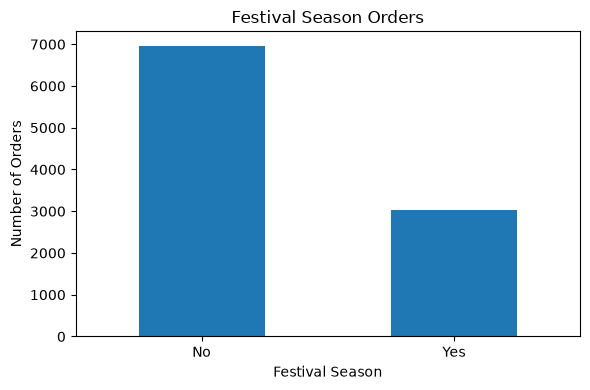

In [48]:
festival.plot(kind="bar", figsize=(6,4))

plt.title("Festival Season Orders")
plt.xlabel("Festival Season")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

The analysis shows that most orders were placed during the non-festival season, while a significant number of orders were also recorded during festival periods. This indicates that customer demand remains consistent throughout the year, with additional sales opportunities during festivals. The company can maximize revenue by introducing special discounts, promotional campaigns, and festive offers during festival seasons.

# Customer Rating Analysis

In [49]:
customer_rating = df["Customer Rating"].value_counts().sort_index()

print(customer_rating)

Customer Rating
1    4848
2    1377
3    1189
4    1417
5    1162
Name: count, dtype: int64


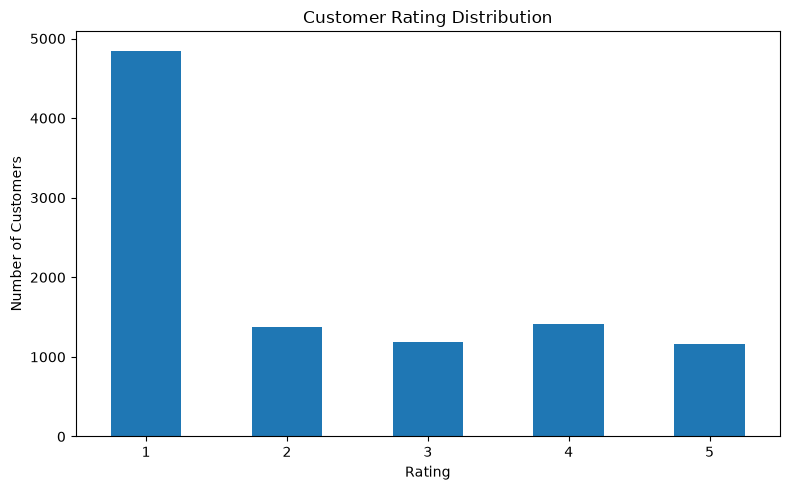

In [50]:
customer_rating.plot(kind="bar", figsize=(8,5))

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

The customer rating analysis helps evaluate customer satisfaction. Higher ratings indicate positive customer experience, while lower ratings suggest areas where the company can improve product quality, delivery, or customer service.

# Warehouse Analysis

In [51]:
warehouse_sales = df.groupby("Warehouse")["Sales"].sum()

print(warehouse_sales)

Warehouse
Bengaluru    391721.9050
Hyderabad    501239.8908
Kolkata      678732.1200
Mumbai       725457.8245
Name: Sales, dtype: float64


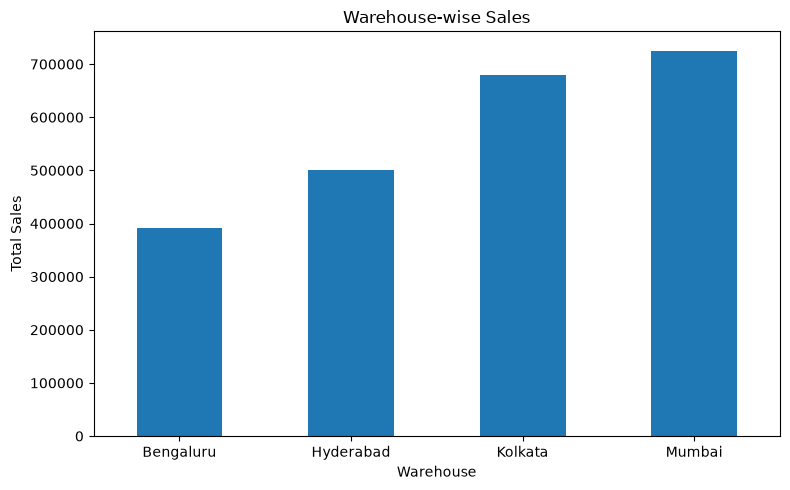

In [52]:
warehouse_sales.plot(kind="bar", figsize=(8,5))

plt.title("Warehouse-wise Sales")
plt.xlabel("Warehouse")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Business Insight

The warehouse-wise sales analysis helps identify which warehouse handles the highest business volume. Warehouses with higher sales may require increased inventory and workforce, while lower-performing warehouses can be optimized for better efficiency.

In [53]:
correlation = df[["Sales", "Quantity", "Discount", "Profit", "Delivery Days", "Customer Rating"]].corr()

print(correlation)

                    Sales  Quantity  Discount    Profit  Delivery Days  \
Sales            1.000000  0.200798 -0.028213  0.479066      -0.005055   
Quantity         0.200798  1.000000  0.008630  0.066253      -0.009922   
Discount        -0.028213  0.008630  1.000000 -0.219496      -0.010642   
Profit           0.479066  0.066253 -0.219496  1.000000      -0.015269   
Delivery Days   -0.005055 -0.009922 -0.010642 -0.015269       1.000000   
Customer Rating  0.525827  0.255889 -0.073186  0.167045      -0.006452   

                 Customer Rating  
Sales                   0.525827  
Quantity                0.255889  
Discount               -0.073186  
Profit                  0.167045  
Delivery Days          -0.006452  
Customer Rating         1.000000  


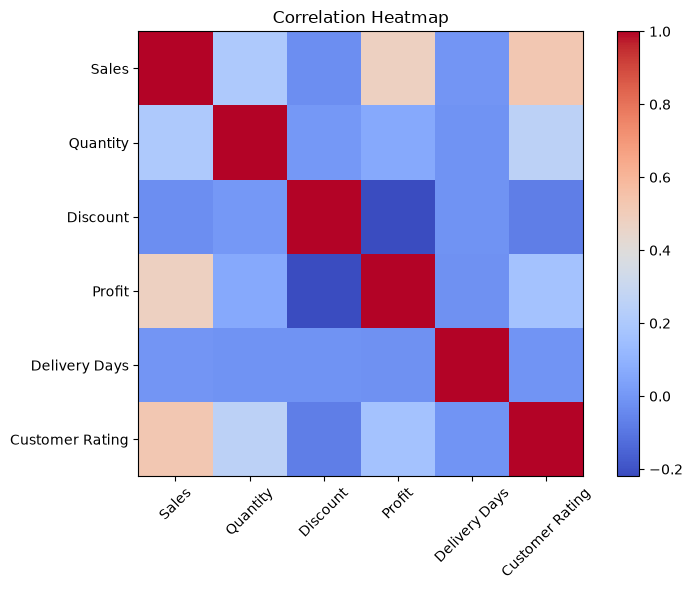

In [54]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# Final Conclusion

### Key Findings

- Technology category generated the highest sales.
- West region recorded the highest sales.
- California was the top-performing state.
- UPI was the most preferred payment method.
- Most orders were successfully delivered.
- Medium priority orders were the most common.
- Non-festival season recorded more orders than festival season.
- The enhanced dataset enabled additional business insights through synthetic business attributes.

In [55]:
df.to_csv("../dataset/Enhanced_Superstore.csv", index=False)

print("Enhanced Dataset Saved Successfully!")

Enhanced Dataset Saved Successfully!


In [61]:
df['Customer Rating'].mean()

np.float64(2.266286400480336)

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("Enhanced_Superstore.csv")

df.head()

,Order_ID,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,...,Quantity,Discount,Profit,Delivery Status,Payment Mode,Order Priority,Festival Season,Delivery Days,Customer Rating,Warehouse
0,ORD1001,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,...,2,0.00,41.9136,Delivered,Cash on Delivery,High,No,1,4,Bengaluru
1,ORD1002,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,...,3,0.00,219.5820,Delivered,Cash on Delivery,High,Yes,2,5,Bengaluru
2,ORD1003,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,...,2,0.00,6.8714,Delivered,Net Banking,High,Yes,2,1,Mumbai
3,ORD1004,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,...,5,0.45,-383.0310,Returned,Credit Card,Medium,No,3,5,Bengaluru
4,ORD1005,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,...,2,0.20,2.5164,Delivered,Credit Card,Low,Yes,6,1,Bengaluru


In [8]:
start_date = "2021-01-01"
end_date = "2024-12-31"

df["Order Date"] = pd.to_datetime(
    np.random.choice(
        pd.date_range(start_date, end_date),
        size=len(df)
    )
)
# Move Order Date to 2nd position
order_date = df.pop("Order Date")
df.insert(1, "Order Date", order_date)

In [9]:
df.head()

,Order_ID,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,...,Quantity,Discount,Profit,Delivery Status,Payment Mode,Order Priority,Festival Season,Delivery Days,Customer Rating,Warehouse
0,ORD1001,2021-10-03,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,2,0.00,41.9136,Delivered,Cash on Delivery,High,No,1,4,Bengaluru
1,ORD1002,2021-07-26,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,3,0.00,219.5820,Delivered,Cash on Delivery,High,Yes,2,5,Bengaluru
2,ORD1003,2021-06-09,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,2,0.00,6.8714,Delivered,Net Banking,High,Yes,2,1,Mumbai
3,ORD1004,2022-07-11,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,5,0.45,-383.0310,Returned,Credit Card,Medium,No,3,5,Bengaluru
4,ORD1005,2023-10-07,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,2,0.20,2.5164,Delivered,Credit Card,Low,Yes,6,1,Bengaluru


In [11]:
df.to_csv("E:\\ECommerce_Sales_Analysis\\dataset\\Enhanced_Superstore.csv", index=False)

In [12]:
df["Year"] = df["Order Date"].dt.year

In [13]:
df["Month"] = df["Order Date"].dt.month_name()

In [14]:
df.head()

,Order_ID,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,...,Profit,Delivery Status,Payment Mode,Order Priority,Festival Season,Delivery Days,Customer Rating,Warehouse,Year,Month
0,ORD1001,2021-10-03,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,41.9136,Delivered,Cash on Delivery,High,No,1,4,Bengaluru,2021,October
1,ORD1002,2021-07-26,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,...,219.5820,Delivered,Cash on Delivery,High,Yes,2,5,Bengaluru,2021,July
2,ORD1003,2021-06-09,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,...,6.8714,Delivered,Net Banking,High,Yes,2,1,Mumbai,2021,June
3,ORD1004,2022-07-11,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,...,-383.0310,Returned,Credit Card,Medium,No,3,5,Bengaluru,2022,July
4,ORD1005,2023-10-07,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,...,2.5164,Delivered,Credit Card,Low,Yes,6,1,Bengaluru,2023,October
